In [87]:
import pandas as pd
import numpy as np
import warnings 
import holidays
import matplotlib.pyplot as plt
import koreanize_matplotlib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')

In [88]:
df2024 = pd.read_csv('../../Data/Zero/2024_data.csv')
df2025 = pd.read_csv('../../Data/Zero/2025_data.csv')
station_meta = pd.read_csv('../../Data/은평구_스테이션_군집화_1차_자전거댓수_추가.csv', encoding='utf-8-sig')
station_meta = station_meta[[
    '대여소_ID', '위도', '경도', 'cluster_12_custom', 'LCD', 'QR'
]].rename(columns={'대여소_ID': '시작_대여소_ID'})
for col in ['위도', '경도', 'cluster_12_custom', 'LCD', 'QR']:
    station_meta[col] = pd.to_numeric(station_meta[col], errors='coerce')

df = pd.concat([df2024,df2025],axis=0)
kr = holidays.KR()

'ST-464', 'ST-481', 'ST-479', 'ST-2247', 'ST-2252', 'ST-2425', 'ST-1027', 'ST-2263', 'ST-3126', 'ST-1035', 'ST-454', 'ST-471', 'ST-1024', 'ST-1023', 'ST-1483','ST-1034', 'ST-462', 'ST-2264'

In [89]:
# 1. 시작 대여소 기준으로만 필터링 (순수 대여량 예측 목적)
target_station = ['ST-464', 'ST-481', 'ST-479', 'ST-2247', 'ST-2252', 'ST-2425', 'ST-1027', 'ST-2263', 'ST-3126', 'ST-1035', 'ST-454', 'ST-471', 'ST-1024', 'ST-1023', 'ST-1483','ST-1034', 'ST-462', 'ST-2264']
df['기준_날짜'] = pd.to_datetime(df['기준_날짜'])
df['year'] = df['기준_날짜'].dt.year
df['weekday'] = df['기준_날짜'].dt.dayofweek
df['day_type'] = np.where(df['weekday'] < 5, 0, 1)
df = df[(df['전체_이용_분'] >= 5) & (df['전체_이용_거리'] >= 5)]
df['datetime'] = pd.to_datetime(df['기준_날짜']) + pd.to_timedelta(df['시간대'], unit='h')
df = df[df['시작_대여소_ID'].isin(target_station)].copy()
df_hourly = df.groupby(['시작_대여소_ID', 'datetime','year']).agg({
    '전체_건수': 'sum',
    '온도': 'mean',
    '습도': 'mean',
    '불쾌지수': 'mean',
    '강수량': 'mean',
    '적설량': 'mean'
}).reset_index()


In [90]:
# 1. 시간대와 요일 정보 다시 추출
df_hourly['hour'] = df_hourly['datetime'].dt.hour
df_hourly['weekday'] = df_hourly['datetime'].dt.dayofweek
df_hourly['is_weekend'] = np.where(df_hourly['weekday'] < 5, 0, 1)
df_hourly['is_holiday'] = df_hourly['datetime'].dt.date.isin(kr)

# 반드시 대여소별로 정렬 후 계산해야 데이터가 꼬이지 않습니다.
df_hourly = df_hourly.sort_values(['시작_대여소_ID', 'datetime'])

# lag 피처는 전체 시간축을 채운 뒤 다시 계산합니다.
base_features = [
    'hour',        # 몇 시인지 (가장 중요!)
    'weekday',     # 무슨 요일인지
    'is_weekend',  # 평일/주말
    '온도', '습도', '불쾌지수', '강수량', '적설량',
    '위도', '경도', 'cluster_12_custom', 'LCD', 'QR',
]

lag_features = [
    'lag_1h', 'lag_2h', 'lag_24h', 'rolling_3h',
    'hour_sin',
    'hour_cos',
    'is_holiday'
]

station_profile_features = [
    'station_mean_count', 'station_std_count',
    'station_weekday_mean_count', 'station_weekend_mean_count'
]

In [91]:
# 1. 모든 대여소와 모든 시간대의 조합을 만듭니다.
if df_hourly.empty or df_hourly['datetime'].notna().sum() == 0:
    raise ValueError('df_hourly의 datetime 컬럼이 비어 있습니다. 기준_날짜/시간대 변환 또는 이전 dropna 결과를 확인하세요.')

all_stations = df_hourly['시작_대여소_ID'].unique()
all_times = pd.date_range(start=df_hourly['datetime'].min(), 
                          end=df_hourly['datetime'].max(), 
                          freq='h')

# 2. 빈 데이터프레임 생성
multi_idx = pd.MultiIndex.from_product([all_stations, all_times], 
                                       names=['시작_대여소_ID', 'datetime'])
df_full = pd.DataFrame(index=multi_idx).reset_index()

# 3. 기존 데이터와 결합
df_hourly = pd.merge(df_full, df_hourly, on=['시작_대여소_ID', 'datetime'], how='left')

# 4. 빈 값 처리
df_hourly['전체_건수'] = df_hourly['전체_건수'].fillna(0) # 대여 없는 시간은 0건
df_hourly['year'] = df_hourly['datetime'].dt.year
df_hourly = df_hourly.merge(station_meta, on='시작_대여소_ID', how='left')
# 날씨 데이터는 직전 시간 값을 채우거나 평균값으로 채움
df_hourly[['온도', '습도', '불쾌지수', '강수량', '적설량']] = \
    df_hourly.groupby('시작_대여소_ID')[['온도', '습도', '불쾌지수', '강수량', '적설량']].ffill()

df_hourly[['온도', '습도', '불쾌지수', '강수량', '적설량']] = \
    df_hourly.groupby('시작_대여소_ID')[['온도', '습도', '불쾌지수', '강수량', '적설량']].bfill()

df_hourly['hour'] = df_hourly['datetime'].dt.hour
df_hourly['weekday'] = df_hourly['datetime'].dt.dayofweek
df_hourly['is_weekend'] = np.where(df_hourly['weekday'] < 5, 0, 1)
df_hourly['is_holiday'] = df_hourly['datetime'].dt.date.isin(kr)
df_hourly = df_hourly.sort_values(['시작_대여소_ID', 'datetime'])

# 전체 시간축 기준으로 lag/rolling 재계산
df_hourly['lag_1h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(1)
df_hourly['lag_2h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(2)
df_hourly['lag_24h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(24)
df_hourly['rolling_3h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].transform(lambda x: x.shift(1).rolling(3).mean())
df_hourly['hour_sin'] = np.sin(2 * np.pi * df_hourly['hour'] / 24)
df_hourly['hour_cos'] = np.cos(2 * np.pi * df_hourly['hour'] / 24)
df_hourly = df_hourly.dropna(subset=['lag_1h', 'lag_2h', 'lag_24h', 'rolling_3h'])

In [92]:
target = '전체_건수'
# features = [
#     '온도',
#     '습도',
#     '불쾌지수',
#     '강수량',
#     '적설량',
# ]

In [93]:
train = df_hourly[df_hourly['year'] == 2024]
test  = df_hourly[df_hourly['year'] == 2025]

# 스테이션 ID 대신 2024년 기준 스테이션 프로필 피처를 부여
train_profile = train.copy()
train_profile['weekday_target'] = train_profile['전체_건수'].where(train_profile['is_weekend'] == 0)
train_profile['weekend_target'] = train_profile['전체_건수'].where(train_profile['is_weekend'] == 1)

station_profile = train_profile.groupby('시작_대여소_ID', as_index=False).agg({
    '전체_건수': 'mean',
    'weekday_target': 'mean',
    'weekend_target': 'mean'
})
station_profile.columns = [
    '시작_대여소_ID', 'station_mean_count', 'station_weekday_mean_count', 'station_weekend_mean_count'
]
station_std = train.groupby('시작_대여소_ID')['전체_건수'].std().reset_index(name='station_std_count')
station_profile = station_profile.merge(station_std, on='시작_대여소_ID', how='left')
station_profile = station_profile.fillna(0)

train = train.merge(station_profile, on='시작_대여소_ID', how='left')
test = test.merge(station_profile, on='시작_대여소_ID', how='left')

features = base_features + lag_features + station_profile_features

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=600,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)

# hgb.fit(X_train, y_train)
# pred_hgb = hgb.predict(X_test)
# print("HGB MAE:", mean_absolute_error(y_test, pred_hgb))
# print("HGB RMSE:", np.sqrt(mean_squared_error(y_test, pred_hgb)))
# print("HGB R2:", r2_score(y_test, pred_hgb))
# 학습할 때
hgb.fit(X_train, np.log1p(y_train))

# 예측할 때 (다시 원래 숫자로 복원)
pred_log = hgb.predict(X_test)
pred_hgb = np.expm1(pred_log)

print("HGB MAE:", mean_absolute_error(y_test, pred_hgb))
print("HGB RMSE:", np.sqrt(mean_squared_error(y_test, pred_hgb)))
print("HGB R2:", r2_score(y_test, pred_hgb))


HGB MAE: 0.467714486764497
HGB RMSE: 1.2607953471138462
HGB R2: 0.6722505163244297


In [94]:
# 데이터 검증: 학습/평가에 쓰인 hourly 데이터 상태 확인
validation_summary = pd.DataFrame({
    '항목': ['전체 행 수', 'datetime 결측 수', '대여소 수', '2024 행 수', '2025 행 수', '전체_건수 평균'],
    '값': [
        len(df_hourly),
        int(df_hourly['datetime'].isna().sum()),
        df_hourly['시작_대여소_ID'].nunique(),
        len(train),
        len(test),
        float(df_hourly['전체_건수'].mean()),
    ]
})

display(validation_summary)
display(df_hourly[['datetime', '시작_대여소_ID', '전체_건수']].head())

,항목,값
0,전체 행 수,315360.000000
1,datetime 결측 수,0.000000
2,대여소 수,18.000000
3,2024 행 수,157680.000000
4,2025 행 수,157680.000000
5,전체_건수 평균,0.715218


,datetime,시작_대여소_ID,전체_건수
24,2024-01-02 00:00:00,ST-1023,0.0
25,2024-01-02 01:00:00,ST-1023,0.0
26,2024-01-02 02:00:00,ST-1023,0.0
27,2024-01-02 03:00:00,ST-1023,0.0
28,2024-01-02 04:00:00,ST-1023,0.0


In [95]:
# 모델 검증 1: persistence baseline(직전 1시간 값)과 비교
baseline_pred = test['lag_1h'].fillna(0).clip(lower=0)

comparison_df = pd.DataFrame({
    '모델': ['Persistence Baseline', 'HistGradientBoosting'],
    'MAE': [
        mean_absolute_error(y_test, baseline_pred),
        mean_absolute_error(y_test, pred_hgb),
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, baseline_pred)),
        np.sqrt(mean_squared_error(y_test, pred_hgb)),
    ],
    'R2': [
        r2_score(y_test, baseline_pred),
        r2_score(y_test, pred_hgb),
    ]
})

display(comparison_df)

,모델,MAE,RMSE,R2
0,Persistence Baseline,0.600101,1.753763,0.365846
1,HistGradientBoosting,0.467714,1.260795,0.672251


In [96]:
# 모델 검증 2: 대여소별 성능과 시간대별 오차 확인
test_result = test[['시작_대여소_ID', 'datetime', 'hour', '전체_건수']].copy()
test_result['예측_건수'] = pred_hgb
test_result['절대오차'] = (test_result['전체_건수'] - test_result['예측_건수']).abs()

station_eval = test_result.groupby('시작_대여소_ID', as_index=False).agg({
    '전체_건수': 'mean',
    '예측_건수': 'mean',
    '절대오차': 'mean'
}).sort_values('절대오차', ascending=False)

hour_eval = test_result.groupby('hour', as_index=False).agg({
    '절대오차': 'mean',
    '전체_건수': 'mean',
    '예측_건수': 'mean'
})

display(station_eval)
display(hour_eval)

,시작_대여소_ID,전체_건수,예측_건수,절대오차
12,ST-454,5.572831,5.190688,2.708861
4,ST-1035,2.658333,2.152395,1.759676
15,ST-471,1.103539,0.835917,1.076704
17,ST-481,0.670548,0.500927,0.735240
16,ST-479,0.422374,0.289694,0.529799
9,ST-2264,0.368721,0.241188,0.479448
14,ST-464,0.245205,0.148235,0.333634
13,ST-462,0.109817,0.104976,0.189926
8,ST-2263,0.089498,0.061699,0.142164
2,ST-1027,0.086416,0.038339,0.116950


,hour,절대오차,전체_건수,예측_건수
0,0,0.483033,0.675951,0.552801
1,1,0.347400,0.447336,0.359502
2,2,0.274237,0.281126,0.265018
3,3,0.213138,0.209132,0.133472
4,4,0.145830,0.103349,0.092956
5,5,0.176154,0.139574,0.085347
6,6,0.287123,0.245205,0.191107
7,7,0.487360,0.497565,0.371343
8,8,0.633043,0.831050,0.581489
9,9,0.389473,0.430441,0.320727


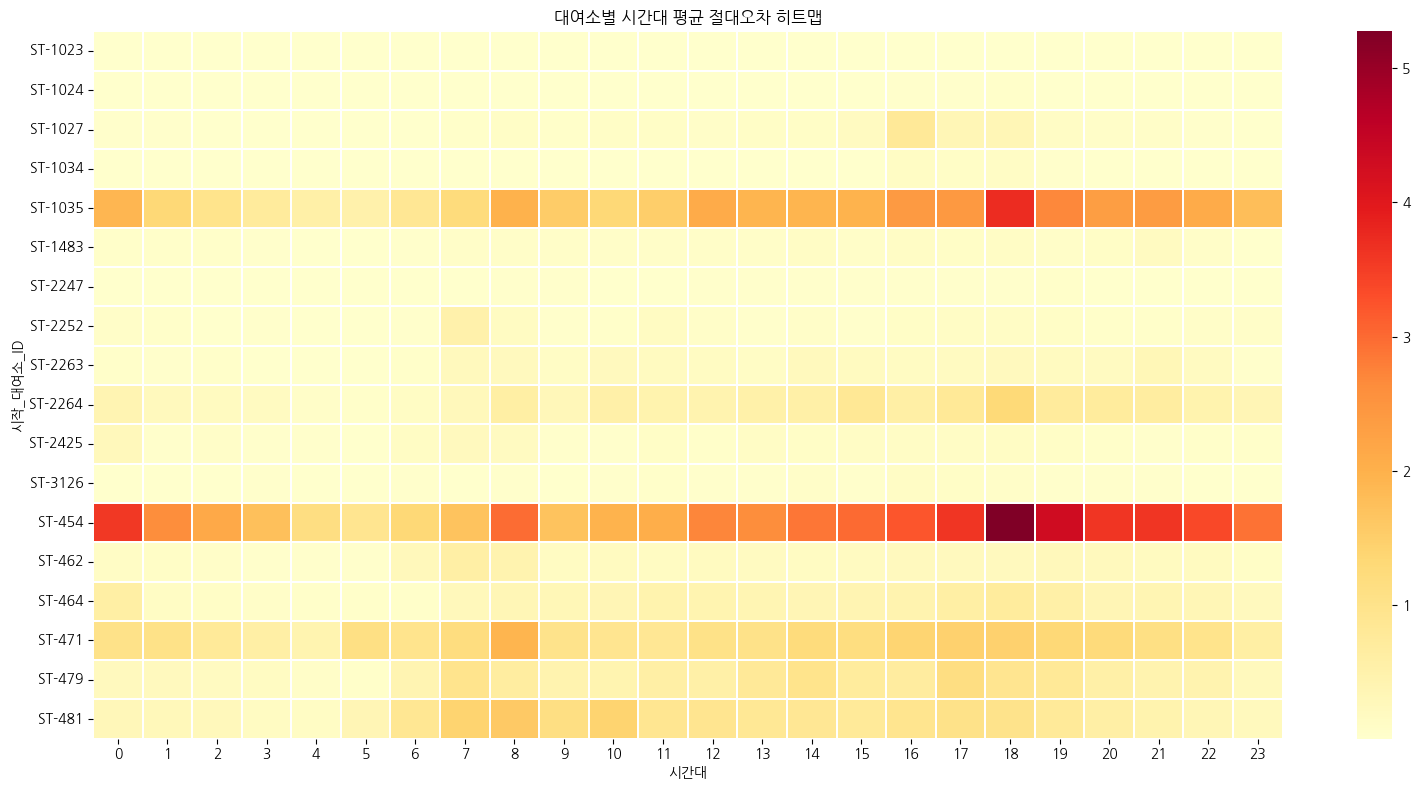

In [97]:
import seaborn as sns

# 시각화 1: 대여소-시간대 평균 절대오차 히트맵
station_hour_error = test_result.groupby(['시작_대여소_ID', 'hour'])['절대오차'].mean().reset_index()
station_hour_pivot = station_hour_error.pivot(index='시작_대여소_ID', columns='hour', values='절대오차')

plt.figure(figsize=(16, 8))
sns.heatmap(station_hour_pivot, cmap='YlOrRd', linewidths=0.2)
plt.title('대여소별 시간대 평균 절대오차 히트맵')
plt.xlabel('시간대')
plt.ylabel('시작_대여소_ID')
plt.tight_layout()
plt.show()

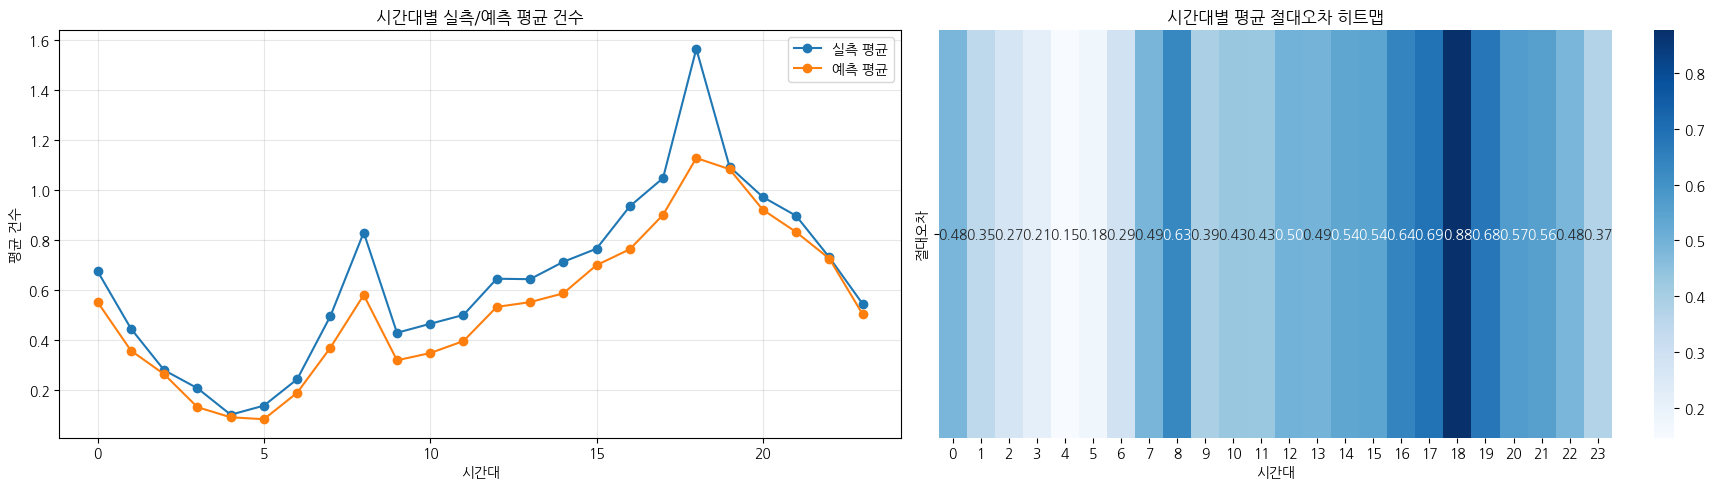

In [98]:
# 시각화 2: 시간대별 실측/예측 평균 비교 + 절대오차 히트맵
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].plot(hour_eval['hour'], hour_eval['전체_건수'], marker='o', label='실측 평균')
axes[0].plot(hour_eval['hour'], hour_eval['예측_건수'], marker='o', label='예측 평균')
axes[0].set_title('시간대별 실측/예측 평균 건수')
axes[0].set_xlabel('시간대')
axes[0].set_ylabel('평균 건수')
axes[0].legend()
axes[0].grid(alpha=0.3)

hour_error_heatmap = hour_eval.set_index('hour')[['절대오차']].T
sns.heatmap(hour_error_heatmap, cmap='Blues', annot=True, fmt='.2f', ax=axes[1])
axes[1].set_title('시간대별 평균 절대오차 히트맵')
axes[1].set_xlabel('시간대')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

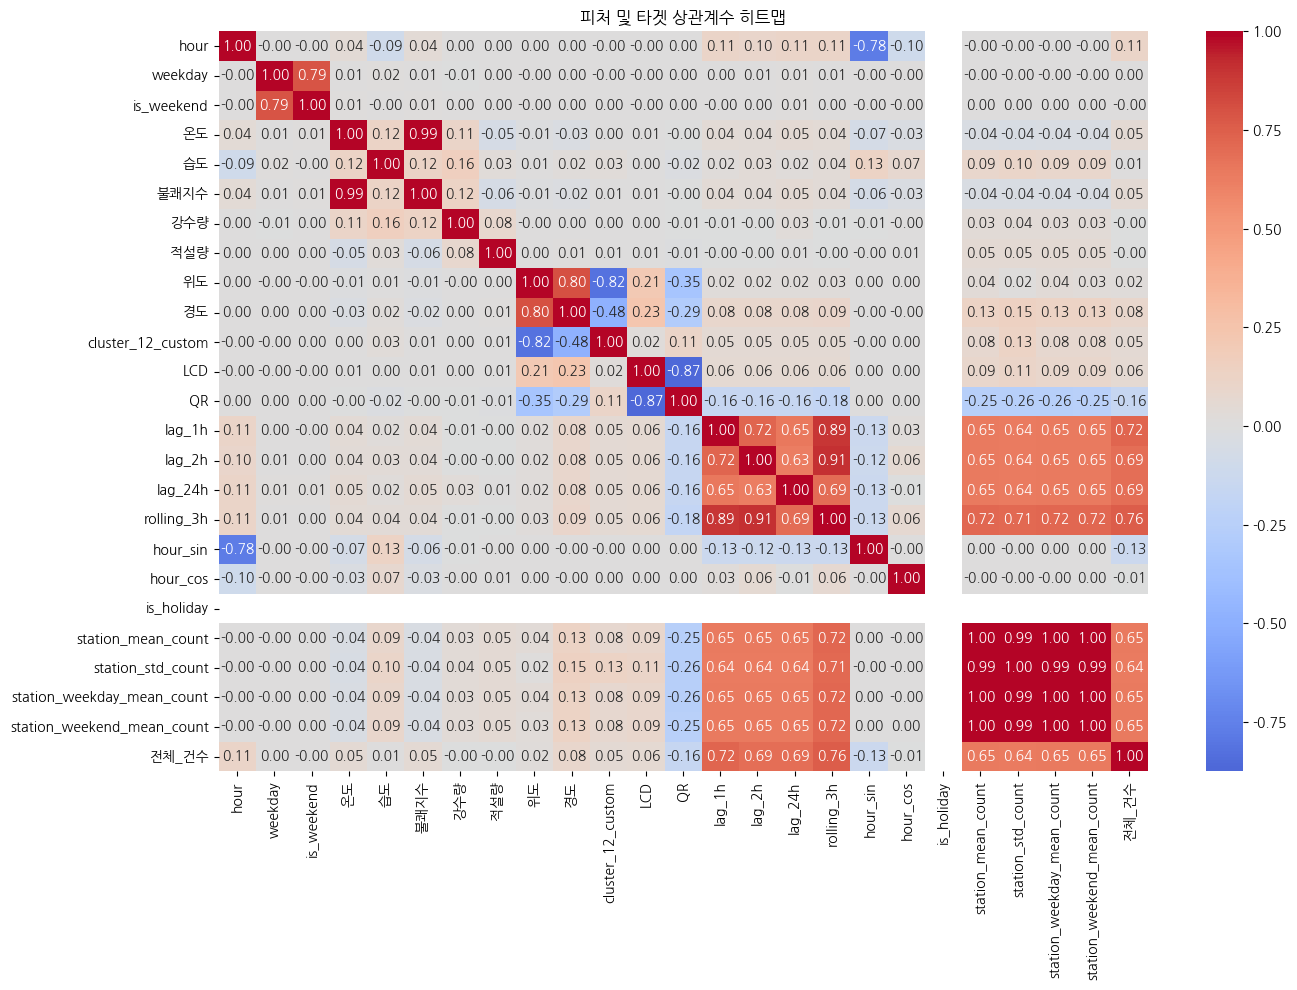

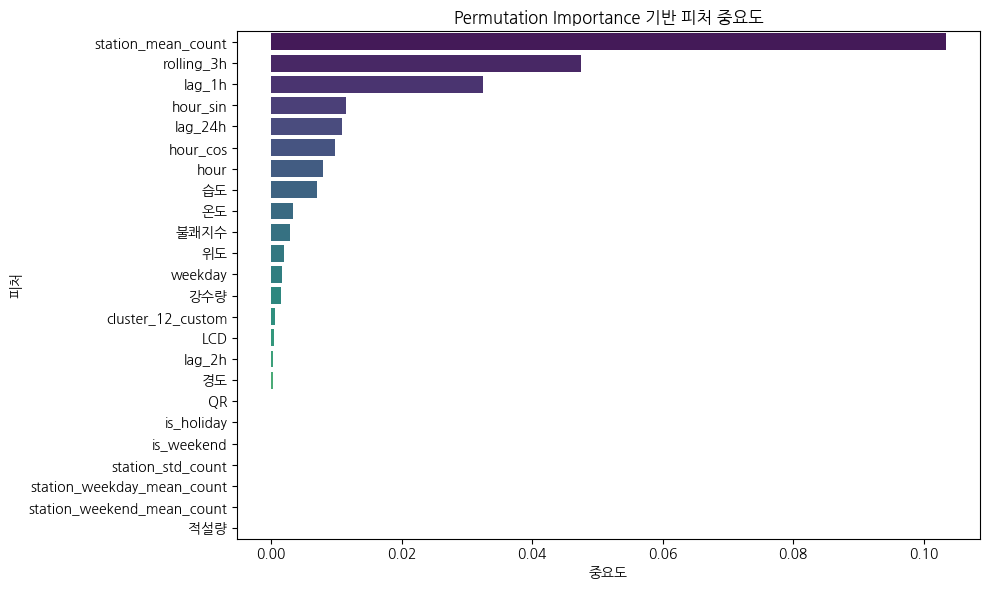

,피처,중요도
20,station_mean_count,0.103428
16,rolling_3h,0.047437
13,lag_1h,0.032451
17,hour_sin,0.011568
15,lag_24h,0.010831
18,hour_cos,0.009831
0,hour,0.007988
4,습도,0.006979
3,온도,0.003340
5,불쾌지수,0.002959


In [99]:
from sklearn.inspection import permutation_importance

# 피처 상관계수 히트맵
corr_cols = features + [target]
corr_df = train[corr_cols].copy()
corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('피처 및 타겟 상관계수 히트맵')
plt.tight_layout()
plt.show()

# permutation importance 기반 피처 중요도
perm_result = permutation_importance(
    hgb,
    X_test,
    np.log1p(y_test),
    n_repeats=5,
    random_state=42,
    scoring='neg_mean_absolute_error'
)

importance_df = pd.DataFrame({
    '피처': features,
    '중요도': perm_result.importances_mean
}).sort_values('중요도', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='중요도', y='피처', palette='viridis')
plt.title('Permutation Importance 기반 피처 중요도')
plt.xlabel('중요도')
plt.ylabel('피처')
plt.tight_layout()
plt.show()

display(importance_df)

In [100]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor

# 비교용 입력 데이터 정리
X_train_cmp = X_train.fillna(0).copy()
X_test_cmp = X_test.fillna(0).copy()
y_train_log = np.log1p(y_train)

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),
    'ExtraTrees': ExtraTreesRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingRegressor(
        learning_rate=0.05,
        n_estimators=200,
        max_depth=3,
        random_state=42
    ),
    'HistGradientBoosting': HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_iter=600,
        max_depth=10,
        min_samples_leaf=10,
        random_state=42
    )
}

model_scores = []
model_predictions = {}

for model_name, model in models.items():
    model.fit(X_train_cmp, y_train_log)
    pred_log = model.predict(X_test_cmp)
    pred = np.expm1(pred_log)
    pred = np.clip(pred, 0, None)

    model_predictions[model_name] = pred
    model_scores.append({
        '모델': model_name,
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R2': r2_score(y_test, pred)
    })

model_score_df = pd.DataFrame(model_scores).sort_values('RMSE')
display(model_score_df)

,모델,MAE,RMSE,R2
5,HistGradientBoosting,0.467704,1.260186,0.672567
3,ExtraTrees,0.472920,1.274640,0.665013
2,RandomForest,0.478151,1.289370,0.657226
4,GradientBoosting,0.491812,1.337413,0.631206
0,LinearRegression,0.552964,1.584346,0.482449
1,Ridge,0.552935,1.584788,0.482161


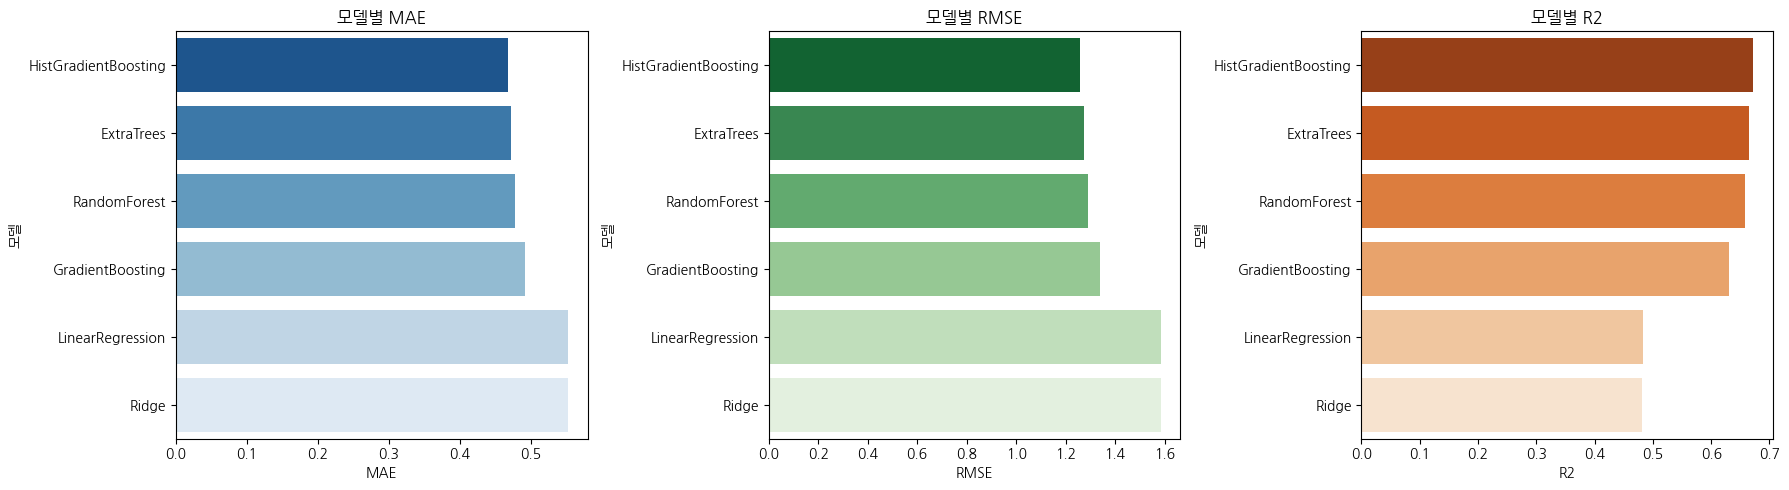

In [101]:
# 모델별 성능 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=model_score_df, x='MAE', y='모델', ax=axes[0], palette='Blues_r')
axes[0].set_title('모델별 MAE')

sns.barplot(data=model_score_df, x='RMSE', y='모델', ax=axes[1], palette='Greens_r')
axes[1].set_title('모델별 RMSE')

sns.barplot(data=model_score_df, x='R2', y='모델', ax=axes[2], palette='Oranges_r')
axes[2].set_title('모델별 R2')

plt.tight_layout()
plt.show()

In [102]:
# 추천 분석 방향: station profile 없이, 시간/날씨/구조/lag 기반 HGB
recommended_features = base_features + lag_features

model_df = df_hourly.copy()
model_df['month'] = model_df['datetime'].dt.month

# 2024년 내부 시계열 검증: 1~9월 학습, 10~12월 검증
train_2024 = model_df[model_df['year'] == 2024].copy()
valid_2024 = train_2024[train_2024['month'] >= 10].copy()
subtrain_2024 = train_2024[train_2024['month'] < 10].copy()
test_2025_reco = model_df[model_df['year'] == 2025].copy()

X_subtrain = subtrain_2024[recommended_features].fillna(0)
y_subtrain = subtrain_2024[target]
X_valid = valid_2024[recommended_features].fillna(0)
y_valid = valid_2024[target]
X_test_reco = test_2025_reco[recommended_features].fillna(0)
y_test_reco = test_2025_reco[target]

recommended_hgb = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=500,
    max_depth=8,
    min_samples_leaf=20,
    l2_regularization=0.1,
    random_state=42
)

recommended_hgb.fit(X_subtrain, np.log1p(y_subtrain))
valid_pred = np.clip(np.expm1(recommended_hgb.predict(X_valid)), 0, None)

validation_result_df = pd.DataFrame({
    '구간': ['2024 holdout (10~12월)'],
    'MAE': [mean_absolute_error(y_valid, valid_pred)],
    'RMSE': [np.sqrt(mean_squared_error(y_valid, valid_pred))],
    'R2': [r2_score(y_valid, valid_pred)]
})

# 2024 전체로 다시 학습 후 2025 테스트 평가
recommended_hgb.fit(train_2024[recommended_features].fillna(0), np.log1p(train_2024[target]))
recommended_pred_2025 = np.clip(
    np.expm1(recommended_hgb.predict(X_test_reco)),
    0,
    None
)

test_result_df = pd.DataFrame({
    '구간': ['2025 test'],
    'MAE': [mean_absolute_error(y_test_reco, recommended_pred_2025)],
    'RMSE': [np.sqrt(mean_squared_error(y_test_reco, recommended_pred_2025))],
    'R2': [r2_score(y_test_reco, recommended_pred_2025)]
})

display(pd.concat([validation_result_df, test_result_df], ignore_index=True))
print('추천 피처 수:', len(recommended_features))
print(recommended_features)

,구간,MAE,RMSE,R2
0,2024 holdout (10~12월),0.531654,1.450104,0.684943
1,2025 test,0.470889,1.269138,0.667899


추천 피처 수: 20
['hour', 'weekday', 'is_weekend', '온도', '습도', '불쾌지수', '강수량', '적설량', '위도', '경도', 'cluster_12_custom', 'LCD', 'QR', 'lag_1h', 'lag_2h', 'lag_24h', 'rolling_3h', 'hour_sin', 'hour_cos', 'is_holiday']


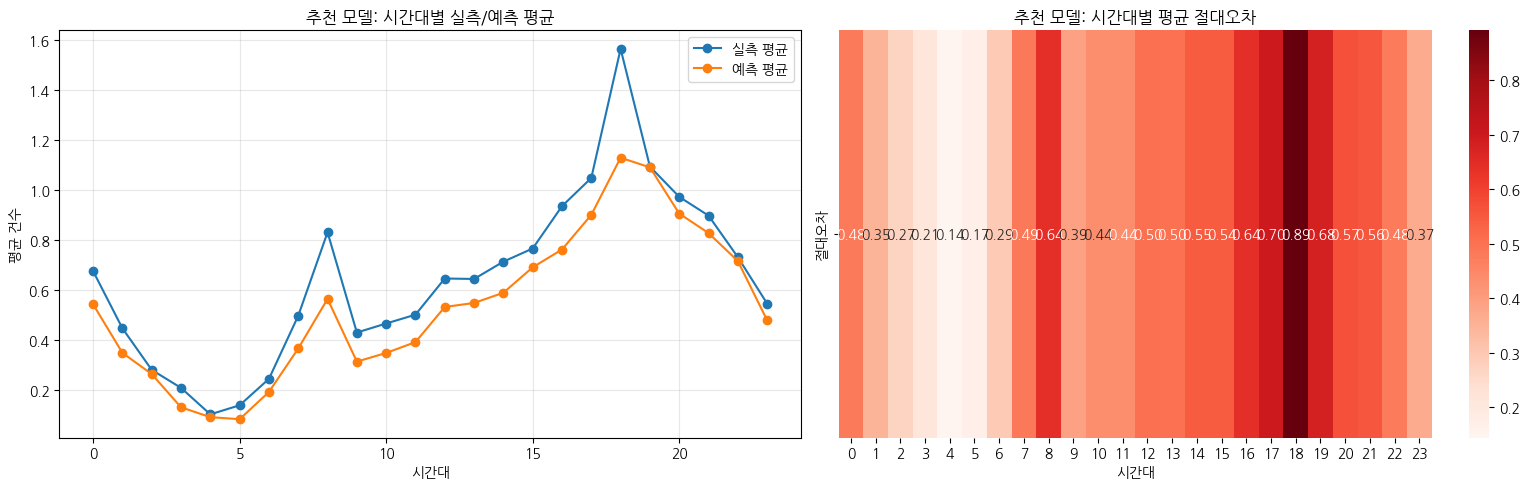

In [103]:
# 추천 모델 결과 시각화
recommended_eval_df = test_2025_reco[['datetime', '시작_대여소_ID', 'hour', '전체_건수']].copy()
recommended_eval_df['예측_건수'] = recommended_pred_2025
recommended_eval_df['절대오차'] = (
    recommended_eval_df['전체_건수'] - recommended_eval_df['예측_건수']
).abs()

recommended_hour_eval = recommended_eval_df.groupby('hour', as_index=False).agg({
    '전체_건수': 'mean',
    '예측_건수': 'mean',
    '절대오차': 'mean'
})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(recommended_hour_eval['hour'], recommended_hour_eval['전체_건수'], marker='o', label='실측 평균')
axes[0].plot(recommended_hour_eval['hour'], recommended_hour_eval['예측_건수'], marker='o', label='예측 평균')
axes[0].set_title('추천 모델: 시간대별 실측/예측 평균')
axes[0].set_xlabel('시간대')
axes[0].set_ylabel('평균 건수')
axes[0].legend()
axes[0].grid(alpha=0.3)

sns.heatmap(
    recommended_hour_eval.set_index('hour')[['절대오차']].T,
    cmap='Reds',
    annot=True,
    fmt='.2f',
    ax=axes[1]
)
axes[1].set_title('추천 모델: 시간대별 평균 절대오차')
axes[1].set_xlabel('시간대')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

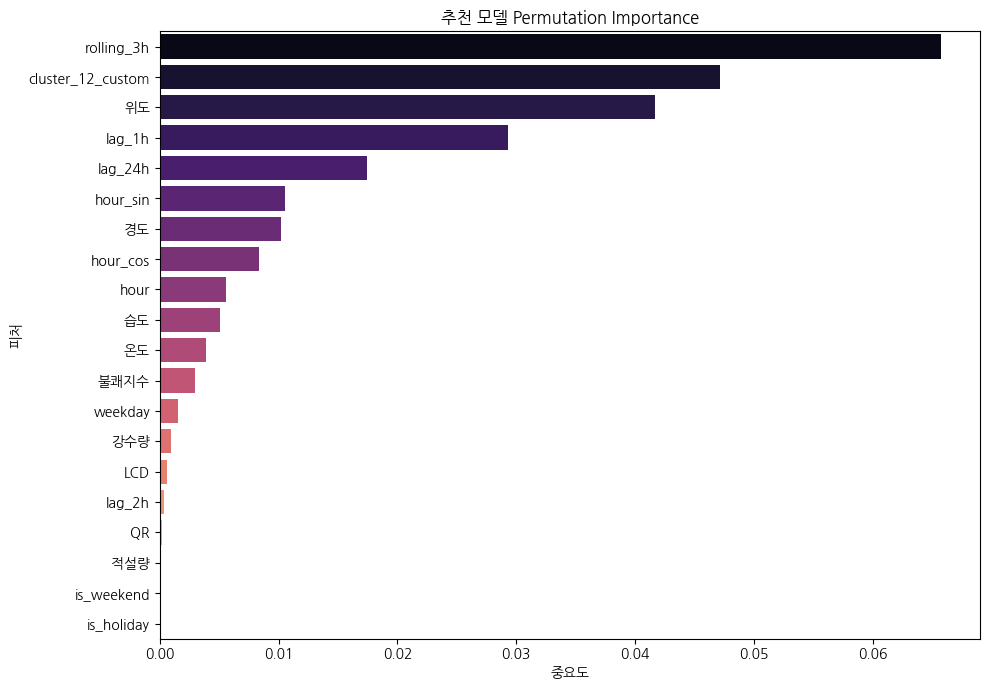

,피처,중요도
16,rolling_3h,0.065733
10,cluster_12_custom,0.047103
8,위도,0.041671
13,lag_1h,0.029293
15,lag_24h,0.017437
17,hour_sin,0.010543
9,경도,0.010162
18,hour_cos,0.008371
0,hour,0.005541
4,습도,0.005078


In [104]:
# 추천 모델 피처 중요도
recommended_perm = permutation_importance(
    recommended_hgb,
    X_test_reco,
    np.log1p(y_test_reco),
    n_repeats=5,
    random_state=42,
    scoring='neg_mean_absolute_error'
)

recommended_importance_df = pd.DataFrame({
    '피처': recommended_features,
    '중요도': recommended_perm.importances_mean
}).sort_values('중요도', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=recommended_importance_df, x='중요도', y='피처', palette='magma')
plt.title('추천 모델 Permutation Importance')
plt.xlabel('중요도')
plt.ylabel('피처')
plt.tight_layout()
plt.show()

display(recommended_importance_df)

## 추천 모델 컬럼 설명

- `hour`: 이용이 발생한 시간대의 시(0~23)
- `weekday`: 요일 숫자. 월요일=0, 일요일=6
- `is_weekend`: 주말 여부. 평일=0, 주말=1
- `온도`: 해당 시간대 기온
- `습도`: 해당 시간대 상대습도
- `불쾌지수`: 온도와 습도로 계산한 체감 불쾌 정도
- `강수량`: 해당 시간대 강수량
- `적설량`: 해당 시간대 적설량
- `위도`: 시작 대여소의 위도
- `경도`: 시작 대여소의 경도
- `cluster_12_custom`: 대여소 군집화 결과 라벨. 비슷한 이용 특성을 가진 대여소 그룹
- `LCD`: 해당 대여소의 LCD 자전거 관련 수량 정보
- `QR`: 해당 대여소의 QR 자전거 관련 수량 정보
- `lag_1h`: 1시간 전 같은 대여소의 전체 대여 건수
- `lag_2h`: 2시간 전 같은 대여소의 전체 대여 건수
- `lag_24h`: 24시간 전 같은 대여소의 전체 대여 건수
- `rolling_3h`: 직전 3시간 대여 건수 평균
- `hour_sin`: 시간대의 주기성을 사인값으로 변환한 피처
- `hour_cos`: 시간대의 주기성을 코사인값으로 변환한 피처
- `is_holiday`: 공휴일 여부. 공휴일=1, 그 외=0

해석 포인트:

- `lag_1h`, `lag_24h`, `rolling_3h`가 높으면 최근 수요 흐름이 중요하다는 뜻입니다.
- `cluster_12_custom`, `위도`, `경도`가 높으면 스테이션의 위치/유형 특성이 중요하다는 뜻입니다.
- `hour`, `hour_sin`, `hour_cos`가 높으면 시간대 패턴이 중요하다는 뜻입니다.
- 날씨 관련 컬럼 중요도가 높으면 기상 조건이 수요 변화에 영향을 준다는 뜻입니다.